In [1]:
import torch
import pandas
import torchvision
import os
from torch.utils.data import Dataset,DataLoader
import scipy.io as scio
# Hyper parameters
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F  # 添加这一行引入torch.nn.functional模块
import copy
import numpy as np
import matplotlib
import time
import h5py
from matplotlib import animation
from sklearn.metrics import confusion_matrix
from matplotlib.animation import FuncAnimation
from matplotlib import pyplot as plt
import hiddenlayer as hl
import pywt
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

In [2]:
class MyDataset(Dataset):
    def __init__(self, root, sets):
        f = h5py.File(root, 'r')
        if sets == 'train':
            self.X = f['X_train'][:]
            self.y = f['y_train'][:]
        elif sets == 'val':
            self.X = f['X_val'][:]
            self.y = f['y_val'][:]
        else:
            self.X = f['X_test'][:]
            self.y = f['y_test'][:]
        f.close()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx]
        if isinstance(x, np.ndarray):
            x = x.astype(np.float32)
        x = torch.from_numpy(x).unsqueeze(0).unsqueeze(-1)
        y = torch.tensor(int(self.y[idx]), dtype=torch.long)
        return x, y

In [3]:
#混合降噪模块

class HybridDenoising(nn.Module):
    def __init__(self, channels=1, wavelet='db4', level=3, learnable_threshold=True):
        """
        混合降噪模块：结合卷积噪声抑制与小波降噪
        参数:
            channels: 输入通道数，默认1
            wavelet: 使用的小波基，默认'db4'
            level: 小波分解层数，默认3
            learnable_threshold: 是否让阈值可学习，默认True
        """
        super(HybridDenoising, self).__init__()
        self.channels = channels
        self.wavelet = wavelet
        self.level = level
        
        # 可学习的卷积噪声抑制层
        self.conv_suppress = nn.Sequential(
            nn.Conv2d(channels, 4, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(4),
            nn.ReLU(inplace=True),
            nn.Conv2d(4, channels, kernel_size=1, bias=False),
            nn.Sigmoid()  # 生成噪声抑制掩码
        )
        
        # 可学习的阈值因子
        self.threshold_factor = nn.Parameter(torch.tensor(1.0), requires_grad=learnable_threshold)
        self.learnable_threshold = learnable_threshold
        
        # 小波系数重要性估计网络
        self.wavelet_importance = nn.Sequential(
            nn.Linear(self.level + 1, 32),
            nn.ReLU(),
            nn.Linear(32, self.level + 1),
            nn.Sigmoid()
        )
    
    def wavelet_denoise(self, signal):
        """应用小波降噪到单个信号"""
        # 小波分解
        coeffs = pywt.wavedec(signal, self.wavelet, level=self.level)
        
        # 估计噪声水平
        if len(coeffs[-1]) > 0:
            sigma = np.median(np.abs(coeffs[-1])) / 0.6745
        else:
            sigma = 1.0  # 避免除以零
        
        # 计算自适应阈值
        threshold = self.threshold_factor.item() * sigma * np.sqrt(2 * np.log(len(signal)))
        
        # 应用阈值处理（保留近似系数）
        thresholded_coeffs = [coeffs[0]]  # 近似系数保持不变
        for i in range(1, len(coeffs)):
            thresholded_coeffs.append(pywt.threshold(coeffs[i], threshold, mode='soft'))
        
        # 小波重构
        denoised_signal = pywt.waverec(thresholded_coeffs, self.wavelet)
        
        # 确保长度匹配
        if len(denoised_signal) > len(signal):
            denoised_signal = denoised_signal[:len(signal)]
        elif len(denoised_signal) < len(signal):
            denoised_signal = np.pad(denoised_signal, (0, len(signal) - len(denoised_signal)), 'constant')
        
        return denoised_signal
    
    def forward(self, x):
        # 第一步：卷积噪声抑制
        conv_mask = self.conv_suppress(x)
        conv_denoised = x * conv_mask
        
        # 第二步：小波降噪（在CPU上执行）
        device = x.device
        x_np = conv_denoised.detach().cpu().numpy()
        
        # 处理批处理维度
        batch_size, channels, height, width = x_np.shape
        denoised_signals = np.zeros_like(x_np)
        
        # 对每个样本和通道应用小波降噪
        for b in range(batch_size):
            for c in range(channels):
                signal = x_np[b, c, :, 0].squeeze()
                denoised_signals[b, c, :, 0] = self.wavelet_denoise(signal)
        
        # 转回PyTorch张量
        wave_denoised = torch.tensor(denoised_signals, dtype=x.dtype).to(device)
        
        # 自适应融合：使用卷积层学习融合权重
        # 修复此处缺少右括号的问题
        fusion_weights = torch.sigmoid(
            torch.mean(conv_mask, dim=[2, 3], keepdim=True))
        
        # 融合结果：在训练阶段保持梯度流
        denoised = fusion_weights * wave_denoised + (1 - fusion_weights) * conv_denoised
        
        # 梯度重定向：确保梯度可以回传到卷积部分
        denoised = denoised + (conv_denoised - conv_denoised.detach())
        
        return denoised

In [4]:
Epoch = 300
Batch_Size = 200
Learning_Rate = 0.001

In [5]:
data_path = 'Geerdataset_bace.h5'
train_dataset = MyDataset(data_path, 'train')
val_dataset = MyDataset(data_path, 'val')
# 自动计算类别数并生成标签名称
NUM_CLASSES = int(len(np.unique(train_dataset.y)))
label_names = [str(i) for i in range(NUM_CLASSES)]

# 查看训练集的结构
for i in range(len(train_dataset)):
    input_data, label_data = train_dataset[i]
    print("Train Sample ", i)
    print("Input Shape:", input_data.shape)
    print("Label Shape:", label_data.shape)
    # 可以根据实际情况打印更多信息

# 查看验证集的结构
for i in range(len(val_dataset)):
    input_data, label_data = val_dataset[i]
    print("Validation Sample ", i)
    print("Input Shape:", input_data.shape)
    print("Label Shape:", label_data.shape)
    # 可以根据实际情况打印更多信息
    
    
train_loader = DataLoader(train_dataset, batch_size=Batch_Size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=Batch_Size, shuffle=True)
# Checking the dataset
for dataset, labels in train_loader:
    print('Signals batch dimensions:', dataset.shape)#四维张量可以被理解为包含200个样本，每个样本有1个通道，
                                                     #每个通道包含1024个元素，每个元素的深度为1
    print('Signals label dimensions:', labels.shape)
    break
print('#training num = %d' % len(train_dataset))
print('#val num = %d' % len(val_dataset))

Train Sample  0
Input Shape: torch.Size([1, 1024, 1])
Label Shape: torch.Size([])
Train Sample  1
Input Shape: torch.Size([1, 1024, 1])
Label Shape: torch.Size([])
Train Sample  2
Input Shape: torch.Size([1, 1024, 1])
Label Shape: torch.Size([])
Train Sample  3
Input Shape: torch.Size([1, 1024, 1])
Label Shape: torch.Size([])
Train Sample  4
Input Shape: torch.Size([1, 1024, 1])
Label Shape: torch.Size([])
Train Sample  5
Input Shape: torch.Size([1, 1024, 1])
Label Shape: torch.Size([])
Train Sample  6
Input Shape: torch.Size([1, 1024, 1])
Label Shape: torch.Size([])
Train Sample  7
Input Shape: torch.Size([1, 1024, 1])
Label Shape: torch.Size([])
Train Sample  8
Input Shape: torch.Size([1, 1024, 1])
Label Shape: torch.Size([])
Train Sample  9
Input Shape: torch.Size([1, 1024, 1])
Label Shape: torch.Size([])
Train Sample  10
Input Shape: torch.Size([1, 1024, 1])
Label Shape: torch.Size([])
Train Sample  11
Input Shape: torch.Size([1, 1024, 1])
Label Shape: torch.Size([])
Train Sample  

In [6]:
class CNN_LSTM_Attention(nn.Module):
    def __init__(self, num_classes=11):
        super(CNN_LSTM_Attention, self).__init__()
        # 添加混合降噪模块
        self.hybrid_denoise = HybridDenoising(channels=1)
        
        # 保持原有CNN结构
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=[16, 1], stride=[7, 1], padding=0, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 32, kernel_size=[7, 1], stride=[4, 1], padding=0, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=[3, 1], stride=[2, 1], padding=0, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )
        self.lstm = nn.LSTM(input_size=17, hidden_size=64, num_layers=2, bias=False, batch_first=True)
        self.attention = nn.MultiheadAttention(embed_dim=64, num_heads=1)
        self.fully_connect = nn.Linear(64, num_classes)
        self.classifier = nn.Softmax(dim=1)

    def forward(self, x):
        # 首先通过混合降噪层
        x = self.hybrid_denoise(x)
        
        # 保持原有前向传播
        residual = x
        x = self.cnn(x)
        residual = F.interpolate(residual, size=x.size()[2:], mode='nearest')
        x = x + residual
        
        y, _ = self.lstm(x.squeeze(3))
        attention_output, _ = self.attention(y, y, y)
        logits = self.fully_connect(attention_output[:, -1, :])
        probs = self.classifier(logits)
        return logits, probs

In [7]:
# 实例化模型
model = CNN_LSTM_Attention(num_classes=NUM_CLASSES)

In [8]:
# 定义优化器和损失函数
optimizer = torch.optim.Adam(model.parameters(), lr=Learning_Rate)
loss_func = nn.CrossEntropyLoss()

epoch 0
Training Accuracy is  0.235
Training Accuracy is  0.220
Training Accuracy is  0.170
Training Accuracy is  0.185
Training Accuracy is  0.205
Training Accuracy is  0.220
Training Accuracy is  0.170
Training Accuracy is  0.240
Training Accuracy is  0.210
Training Accuracy is  0.165
Training Accuracy is  0.245
epoch 1
Training Accuracy is  0.215
Training Accuracy is  0.220
Training Accuracy is  0.200
Training Accuracy is  0.185
Training Accuracy is  0.190
Training Accuracy is  0.235
Training Accuracy is  0.195
Training Accuracy is  0.185
Training Accuracy is  0.235
Validation Accuracy is  0.165
Validation Accuracy is  0.240
Validation Accuracy is  0.195
Validation Accuracy is  0.190
Validation Accuracy is  0.260
Validation Accuracy is  0.190
Validation Accuracy is  0.265
Validation Accuracy is  0.175
Validation Accuracy is  0.205
Validation Accuracy is  0.210
Validation Accuracy is  0.190
Training Accuracy is  0.185
Training Accuracy is  0.230
epoch 2
Training Accuracy is  0.250
Tr

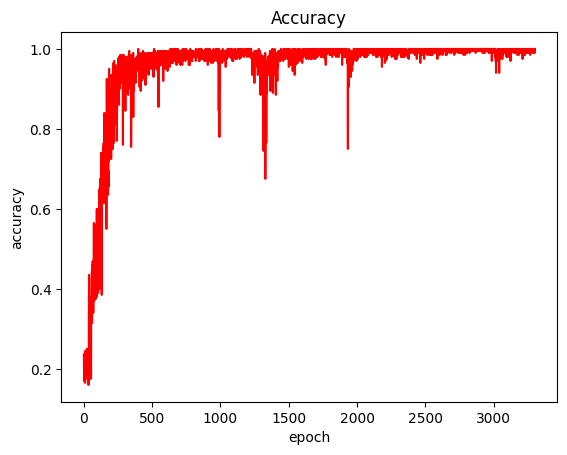

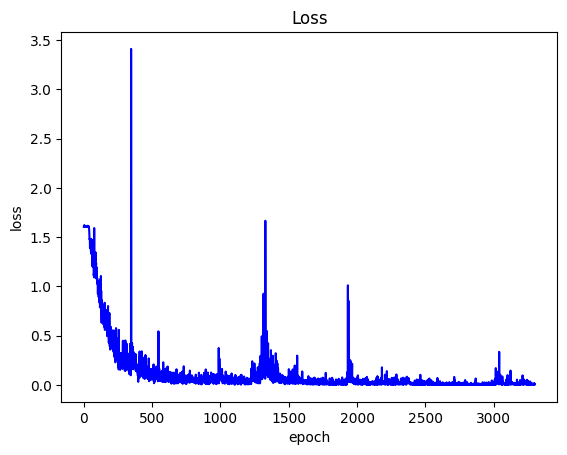

In [9]:
use_cuda = torch.cuda.is_available()
if use_cuda:
    print('CUDA is available')
device = torch.device('cuda:0' if use_cuda else "cpu")
# device = torch.device("cpu")
model = model.to(device)
# save best_model wrt. val_acc
best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0
Best_Acc = 0.0
loss_list = []
acc_list =[]
val_acc_list = []
val_loss_list = []
global_step = []

history = hl.History()
canvas = hl.Canvas()

for epoch in range(Epoch):
    print ("epoch", epoch)
    for step, (XTrain, YTrain) in enumerate(train_loader):
        num_correct = 0
        model.train()
        XTrain, YTrain = XTrain.float(), YTrain.long()
        XTrain, YTrain = XTrain.to(device), YTrain.to(device)
        logits, probas = model(XTrain)
        loss = loss_func(logits, YTrain)
        preds = probas.max(1, keepdim=True)[1]
        acc = preds.eq(YTrain.view_as(preds)).sum().item() / len(YTrain)
        print("Training Accuracy is %6.3f" % acc)
        loss_list.append(loss)
        acc_list.append(acc)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        global_step.append(epoch * len(train_loader) + step + 1)

        if len(global_step) % 20 == 0:
            model.eval()
            with torch.no_grad():
                for XValidation, YValidation in val_loader:
                    XValidation, YValidation = XValidation.float(), YValidation.long()
                    XValidation, YValidation = XValidation.to(device), YValidation.to(device)
                    val_logits, val_probas = model(XValidation)
                    val_loss = loss_func(val_logits, YValidation)
                    val_loss_list.append(val_loss)
                    val_preds = val_probas.max(1, keepdim=True)[1]
                    val_acc = val_preds.eq(YValidation.view_as(val_preds)).sum().item() / len(YValidation)
                    print("Validation Accuracy is %6.3f" % val_acc)
                    val_acc_list.append(val_acc)
                    if val_acc > best_acc:
                        best_acc = val_acc
                        best_model_wts = copy.deepcopy(model.state_dict())

# 存储最佳验证的模型
torch.save(best_model_wts, 'Dnn_wave_model.pkl')
#绘图
plt.figure(1)
plt.plot(global_step ,acc_list,'r-')
plt.title('Accuracy')
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.savefig('Dnn_wave_acc.jpg')
plt.show()

#plt.clf()
plt.figure(2)
loss_list = [loss.cpu().detach().numpy() for loss in loss_list]  
plt.plot(global_step, loss_list, 'b-')
plt.title('Loss')
plt.xlabel("epoch")
plt.ylabel("loss")
plt.savefig('Dnn_wave_loss.jpg')
plt.show()

#test num = 2200
Average Test Accuracy: 98.6773%


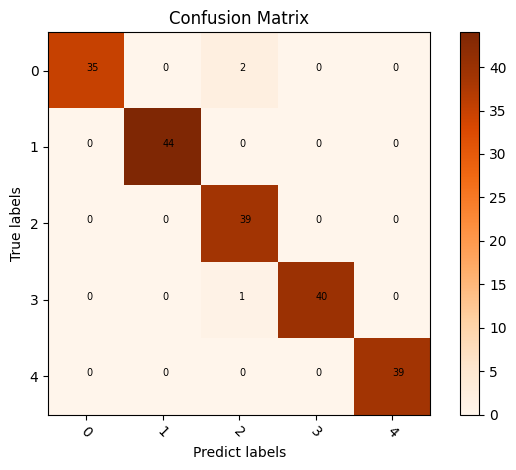

Correct_samples: 197
Total_samples: 200
Test Accuracy: 98.5000%


In [10]:
BATCH_SIZE=200 
test_acc_mean = [] 
test_dataset = MyDataset(data_path,'test')

# 查看测试集的结构
for i in range(len(test_dataset)):
    input_data, label_data = test_dataset[i]
    #print("Test Sample ", i)
    #print("Input Shape:", input_data.shape)
    #print("Label Shape:", label_data.shape)
    # 可以根据实际情况打印更多信息
    
print('#test num = %d' % len(test_dataset))
    
test_loader = DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=True)

def restore_params(): # load the params of the net 
    models = CNN_LSTM_Attention(num_classes=NUM_CLASSES)
    models.load_state_dict(torch.load('Dnn_wave_model.pkl'))
    return models

test_acc_list = []
con_matrix = np.zeros([NUM_CLASSES, NUM_CLASSES])
for i in range(10):
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)   # BATCH_SIZE,1,1024,1
    mymodel = restore_params()
    use_cuda = torch.cuda.is_available()
    if use_cuda:
        print('CUDA is available') 
    device = torch.device("cuda" if use_cuda else "cpu")
    mymodel = mymodel.to(device)
    for XTest, YTest in test_loader:
        XTest, YTest = XTest.float(), YTest.long()
        XTest, YTest = XTest.to(device), YTest.to(device)
        test_logits, test_probas = mymodel(XTest)
        test_preds = test_probas.max(1, keepdim=True)[1]
        test_acc = test_preds.eq(YTest.view_as(test_preds)).sum().item() / len(YTest)
        #cm = confusion_matrix(YTest, test_preds)
        cm = confusion_matrix(YTest.cpu(), test_preds.cpu())
        con_matrix += cm
        test_acc_list.append(test_acc)
        
# 计算平均测试准确率
average_test_acc = sum(test_acc_list) / len(test_acc_list)
print("Average Test Accuracy: {:.4f}%".format(average_test_acc * 100))

# visualization the Network
from matplotlib import pyplot as plt
classes = label_names
yourconfusion = np.array(cm)
plt.imshow(yourconfusion, interpolation='nearest', cmap=plt.cm.Oranges)  #按照像素显示出矩阵
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=-45)
plt.yticks(tick_marks, classes)
thresh = yourconfusion.max() / 2.
iters = [[i,j] for i in range(len(classes)) for j in range((len(classes)))]
for i, j in iters:
    plt.text(j, i, format(yourconfusion [i, j]), fontsize=7)

plt.ylabel('True labels')
plt.xlabel('Predict labels')
plt.tight_layout()
plt.savefig('Bace_wave_confusion_matrix.jpg')
plt.show()

# 根据混淆矩阵计算测试精度
true_positives = yourconfusion.diagonal().sum()
print("Correct_samples: {}".format(true_positives))
total_samples = yourconfusion.sum()
print("Total_samples: {}".format(total_samples))
test_accuracy = true_positives / total_samples
print("Test Accuracy: {:.4f}%".format(test_accuracy * 100))